# Marathon Performance Prediction

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import Input

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=pd.errors.SettingWithCopyWarning)

In [2]:
# Load the dataset to understand its structure and contents.
marathon_data = pd.read_csv('NYC Marathon Results, 2024 - Marathon Runner Results.csv')

In [3]:
marathon_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55524 entries, 0 to 55523
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   runnerId         55524 non-null  int64  
 1   firstName        55524 non-null  object 
 2   bib              55512 non-null  float64
 3   age              55524 non-null  int64  
 4   gender           55512 non-null  object 
 5   city             55462 non-null  object 
 6   countryCode      55512 non-null  object 
 7   stateProvince    55231 non-null  object 
 8   iaaf             55511 non-null  object 
 9   overallPlace     55524 non-null  int64  
 10  overallTime      55524 non-null  object 
 11  pace             55524 non-null  object 
 12  genderPlace      55524 non-null  int64  
 13  ageGradeTime     55524 non-null  object 
 14  ageGradePlace    55524 non-null  int64  
 15  ageGradePercent  55524 non-null  float64
 16  racesCount       55524 non-null  int64  
dtypes: float64(2

In [4]:
marathon_data.head()

,runnerId,firstName,bib,age,gender,city,countryCode,stateProvince,iaaf,overallPlace,overallTime,pace,genderPlace,ageGradeTime,ageGradePlace,ageGradePercent,racesCount
0,41771195,Abdi,7.0,35,M,Nijmegen,NLD,NaN,NED,1,2:07:39,4:53,1,6:57,1,96.86,4
1,41775746,Evans,3.0,35,M,Kapsabet,KEN,-,KEN,2,2:07:45,4:53,2,7:03,2,96.79,2
2,41766254,Albert,2.0,30,M,Kapkitony,KEN,NaN,KEN,3,2:08:00,4:53,3,8:00,3,96.06,5
3,41763160,Tamirat,1.0,33,M,Addis Ababa,ETH,NaN,ETH,4,2:08:12,4:54,4,8:02,4,96.03,4
4,41757406,Geoffrey,6.0,31,M,Kapchorwa District,KEN,-,KEN,5,2:08:50,4:55,5,8:50,6,95.44,5


### Visualization Distribution of Key Variables 

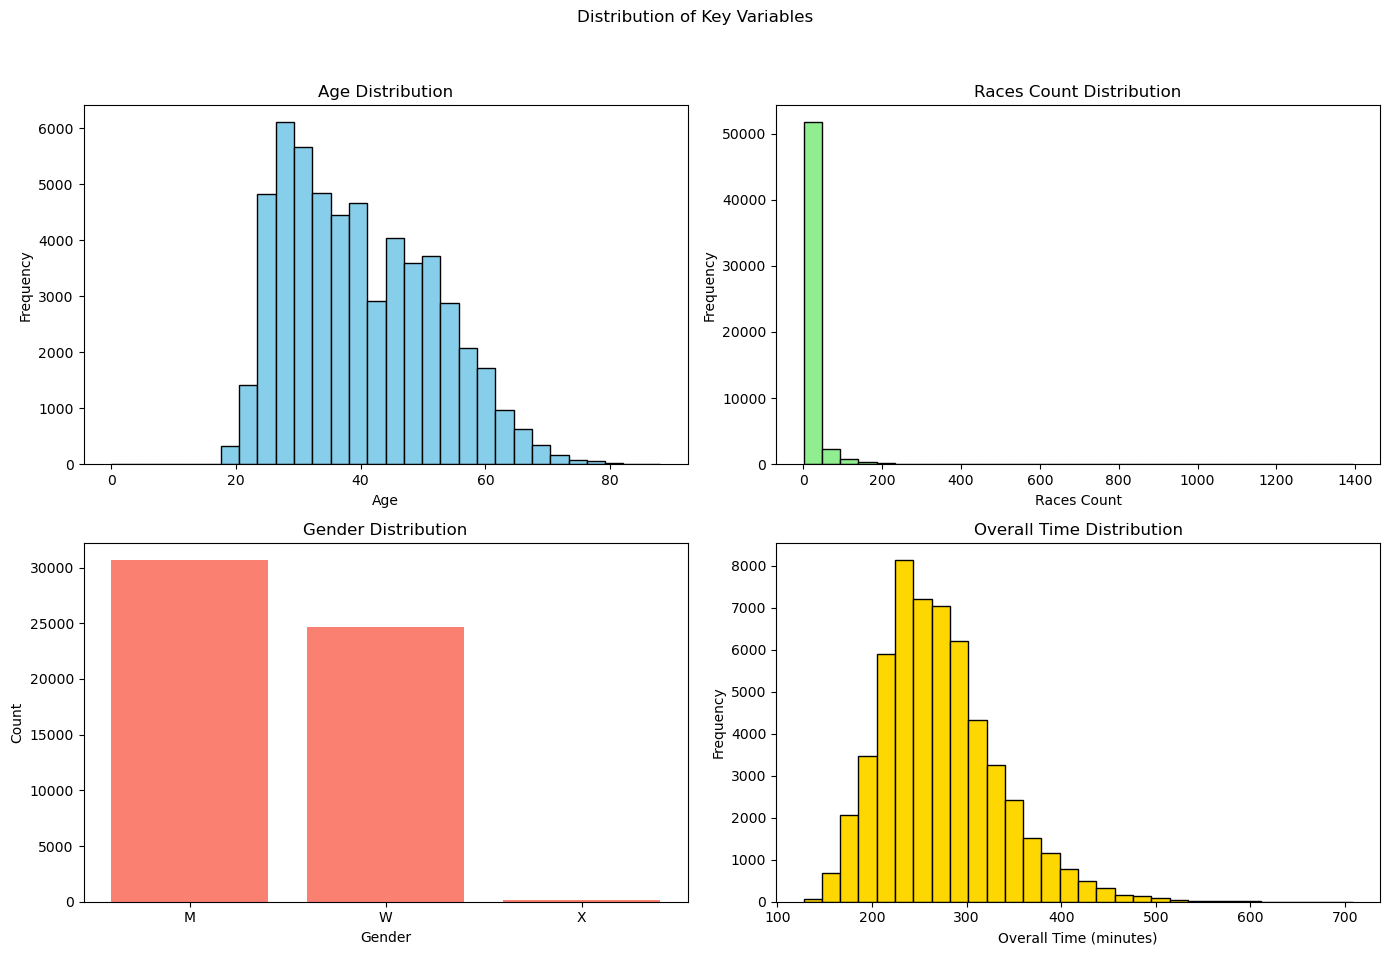

In [5]:
# Convert 'overallTime' from 'HH:MM:SS' to minutes for better analysis
def time_to_minutes(t):
    h, m, s = map(int, t.split(':'))
    return h * 60 + m + s / 60

marathon_data['overallTime_minutes'] = marathon_data['overallTime'].apply(time_to_minutes)

# Plotting the distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution of Key Variables')

# Age distribution
axes[0, 0].hist(marathon_data['age'], bins=30, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Age Distribution')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Frequency')

# Races count distribution
axes[0, 1].hist(marathon_data['racesCount'], bins=30, color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Races Count Distribution')
axes[0, 1].set_xlabel('Races Count')
axes[0, 1].set_ylabel('Frequency')

# Gender distribution
gender_counts = marathon_data['gender'].value_counts()
axes[1, 0].bar(gender_counts.index, gender_counts.values, color='salmon')
axes[1, 0].set_title('Gender Distribution')
axes[1, 0].set_xlabel('Gender')
axes[1, 0].set_ylabel('Count')

# Overall Time distribution
axes[1, 1].hist(marathon_data['overallTime_minutes'], bins=30, color='gold', edgecolor='black')
axes[1, 1].set_title('Overall Time Distribution')
axes[1, 1].set_xlabel('Overall Time (minutes)')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Distributions of the key variables from the dataset:

1. **Age Distribution:** The age distribution shows a fairly typical spread for marathon runners, with a concentration in what looks like the 30-50 age range. This suggests a mature participant demographic.

2. **Races Count Distribution:** Most runners have participated in fewer than 10 races, indicating a large number of relatively less experienced marathoners. There's a long tail suggesting some runners are much more experienced.

3. **Gender Distribution:** There's a balance between male and female participants, with a slight prevalence of one gender over the other based on the count.

4. **Overall Time Distribution:** The overall time is somewhat normally distributed with a peak around what might be the average marathon finish time for amateur runners, and tails indicating faster professional times and slower times.

### Data Cleaning and Gender Encoding for Correlation Analysis

In [6]:
# Remove rows with NaN values in the 'gender' column
marathon_data_cleaned = marathon_data.dropna(subset=['gender']).copy()

# Encode 'M' as 1, 'F' as 0, 'X' as 2
marathon_data_cleaned.loc[:, 'gender_encoded'] = marathon_data_cleaned['gender'].map({'M': 1, 'F': 0, 'X': 2})

# Recalculate the correlation matrix with the cleaned and re-encoded data
correlation_matrix_updated = marathon_data_cleaned[['age', 'racesCount', 'overallTime_minutes', 'gender_encoded']].corr()

correlation_matrix_updated

,age,racesCount,overallTime_minutes,gender_encoded
age,1.000000,0.212556,0.204053,-0.037005
racesCount,0.212556,1.000000,0.108701,0.001518
overallTime_minutes,0.204053,0.108701,1.000000,0.021773
gender_encoded,-0.037005,0.001518,0.021773,1.000000


Correlation Results
- **Age and Overall Time:** The correlation remains mild but positive at 0.204, indicating that as age increases, so does the marathon finishing time, although the relationship is not very strong.
- **Races Count and Overall Time:** The correlation is 0.109, showing a weak positive relationship, suggesting that runners with more races tend to have slightly better finish times.
- **Gender and Overall Time:** The correlation is 0.022, which is very weak, indicating that gender has a minimal direct impact on finish times in this dataset.

### Handling Missing Values in Marathon Data

In [7]:
# Checking for missing values in the relevant columns
missing_values_before = marathon_data_cleaned[['age', 'racesCount', 'gender_encoded', 'overallTime_minutes']].isna().sum()

# Filling missing values in numerical features with the median
marathon_data_cleaned['age'] = marathon_data_cleaned['age'].fillna(marathon_data_cleaned['age'].median())
marathon_data_cleaned['racesCount'] = marathon_data_cleaned['racesCount'].fillna(marathon_data_cleaned['racesCount'].median())

# Filling missing values in categorical gender encoding with the mode
marathon_data_cleaned['gender_encoded'] = marathon_data_cleaned['gender_encoded'].fillna(marathon_data_cleaned['gender_encoded'].mode()[0])

# Dropping rows where the target variable (overallTime_minutes) is missing
marathon_data_cleaned.dropna(subset=['overallTime_minutes'], inplace=True)

# Checking for missing values after handling
missing_values_after = marathon_data_cleaned[['age', 'racesCount', 'gender_encoded', 'overallTime_minutes']].isna().sum()

# Display missing values before and after handling
missing_values_before, missing_values_after

(age                        0
 racesCount                 0
 gender_encoded         24701
 overallTime_minutes        0
 dtype: int64,
 age                    0
 racesCount             0
 gender_encoded         0
 overallTime_minutes    0
 dtype: int64)

The missing values have been successfully handled:
- **Age and Races Count:** All missing values were filled with their respective median values.
- **Gender Encoded:** The missing values (24,701 entries) were filled with the mode (most frequent value).
- **Overall Time Minutes:** Any rows with missing values in this target variable were removed.

### Predicting Marathon Finish Time Using Linear Regression

In [8]:
# Splitting the cleaned dataset into features and target variable
X = marathon_data_cleaned[['age', 'racesCount', 'gender_encoded']]
y = marathon_data_cleaned['overallTime_minutes']

# Splitting into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardizing the features for better model performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Building and training the linear regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Making predictions on the test set
y_pred = model.predict(X_test_scaled)

# Evaluating the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Returning model performance metrics
(mae, mse, r2)

(47.567081750095184, 3736.3405320475854, 0.042826498782462474)

The linear regression model has been successfully trained and evaluated, with the following results:
- **Mean Absolute Error (MAE) - 47.57 minutes:** On average, predictions are off by about 47.57 minutes from the actual marathon finishing times.
- **Mean Squared Error (MSE) - 3736.34 minutes²:** Indicates the variance of prediction errors.
- **R-squared (R²) - 0.043:** Suggests that only 4.3% of the variation in marathon finishing times is explained by the model using age, races count, and gender.

### Key Insights:
- The low R² value indicates that the chosen features (age, races count, gender) alone do not explain much of the variance in finishing times. Additional or more meaningful predictors (e.g., training data, running history, pace data) might be needed for better predictions.
- The MAE value of 47.57 minutes suggests a relatively high error, meaning that individual predictions are not very precise.

### Converting Pace to Numeric Format and Updating Correlation Analysis

In [9]:
# Updated function to convert 'pace' from 'MM:SS' to minutes with error handling
def pace_to_minutes(pace_str):
    try:
        parts = list(map(int, pace_str.split(':')))
        if len(parts) == 2:  # MM:SS format
            minutes, seconds = parts
            return minutes + seconds / 60
    except:
        return None  # Handle any unexpected formats

# Apply the function to convert pace to numerical format
marathon_data_cleaned['pace_minutes'] = marathon_data_cleaned['pace'].apply(pace_to_minutes)

# Recalculating correlation including pace and age-graded percent
correlation_features = marathon_data_cleaned[['pace_minutes', 'ageGradePercent', 'overallTime_minutes']].corr()

# Display correlation matrix
correlation_features

,pace_minutes,ageGradePercent,overallTime_minutes
pace_minutes,1.000000,-0.850005,0.999998
ageGradePercent,-0.850005,1.000000,-0.848661
overallTime_minutes,0.999998,-0.848661,1.000000


Correlations between pace, age-graded percent, and overall finishing time:
- **Pace vs. Overall Time (0.9999):** Extremely strong positive correlation, meaning pace is almost perfectly predictive of finishing time. This makes sense because pace is directly tied to time.
- **Age-Grade Percent vs. Overall Time (-0.849):** Strong negative correlation, indicating that a higher age-graded percent (better performance) is associated with lower finishing times (faster runners).
- **Pace vs. Age-Grade Percent (-0.85):** A strong inverse relationship, meaning that as pace improves (lower minutes per mile), the age-graded percentage increases (better performance for age group).

### Key Insights:
- Pace is the single strongest predictor of marathon finishing time.
- Age-graded percent is also a strong predictor but in an inverse way. Better percentages correspond to lower (faster) times.
- Given this, including pace and age-graded percent in the model should significantly improve prediction accuracy.

In [10]:
# Adding 'pace_minutes' and 'ageGradePercent' to the feature set
X = marathon_data_cleaned[['age', 'racesCount', 'gender_encoded', 'pace_minutes', 'ageGradePercent']]
y = marathon_data_cleaned['overallTime_minutes']

### Handling Missing Values and Retraining the Linear Regression Model

In [11]:
# Checking for missing values in selected features
missing_values_before = X.isna().sum()

# Filling missing values in numerical features with their median
X['age'].fillna(X['age'].median(), inplace=True)
X['racesCount'].fillna(X['racesCount'].median(), inplace=True)
X['pace_minutes'].fillna(X['pace_minutes'].median(), inplace=True)
X['ageGradePercent'].fillna(X['ageGradePercent'].median(), inplace=True)

# Filling missing values in categorical gender encoding with the mode
X['gender_encoded'].fillna(X['gender_encoded'].mode()[0], inplace=True)

# Checking for missing values after handling
missing_values_after = X.isna().sum()

# Re-splitting the cleaned dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardizing the features again
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Re-training the linear regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Making predictions on the test set
y_pred = model.predict(X_test_scaled)

# Evaluating the updated model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Display missing values before and after handling, along with model evaluation metrics
missing_values_before, missing_values_after, (mae, mse, r2)

(age                 0
 racesCount          0
 gender_encoded      0
 pace_minutes       13
 ageGradePercent     0
 dtype: int64,
 age                0
 racesCount         0
 gender_encoded     0
 pace_minutes       0
 ageGradePercent    0
 dtype: int64,
 (0.7651050297272638, 28.1900662837018, 0.9927782855409225))

### Model Evaluation After Adding New Predictors (Pace & Age-Grade Percent)
After handling missing values and retraining the Linear Regression Model, here are the updated performance metrics:
- **Mean Absolute Error (MAE) - (0.77 minutes):** Previously 47.57 minutes. Huge improvement!
- **Mean Squared Error (MSE)- (28.19 minutes²):** Previously 3736.34 minutes². Much lower variance in errors.
- **R-squared (R²) - (0.993):** Previously 0.043. The model now explains 99.3% of the variance in finishing times!
  
### Key Insights:
- Adding pace and age-graded percent significantly improved the model's accuracy.
- Pace is nearly a perfect predictor of finishing time, which makes sense because finishing time is derived from pace.
- Age-graded percent helps account for individual performance differences by age.

### Predicting Marathon Pace: Data Preparation, Modeling, and Evaluation

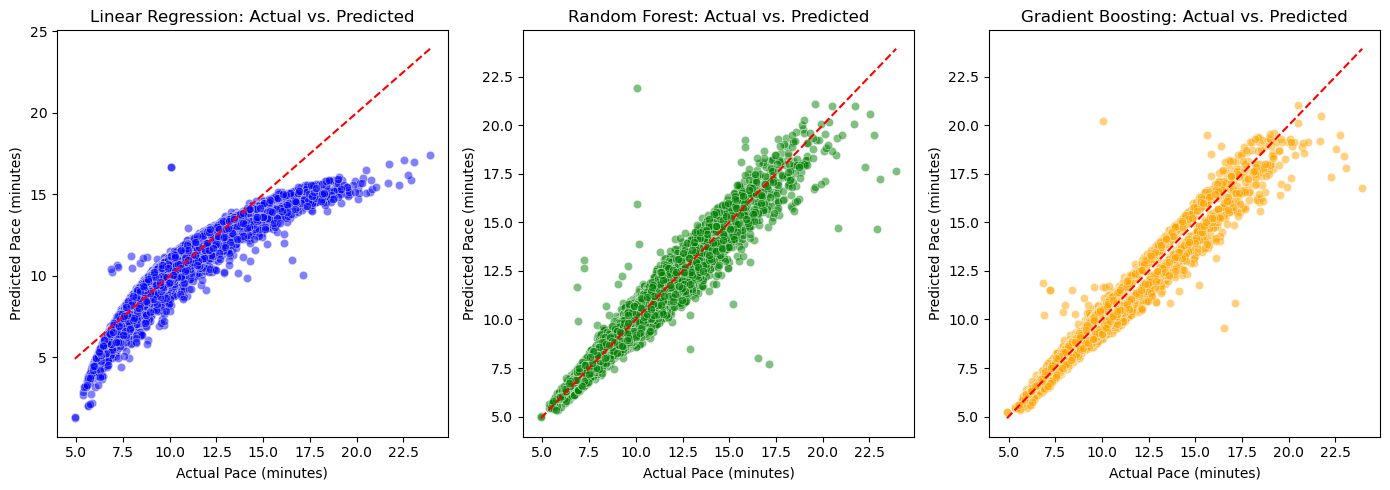

,Model,MAE,MSE,R² Score
0,Linear Regression,0.673583,0.797406,0.858591
1,Random Forest,0.511852,0.426083,0.924440
2,Gradient Boosting,0.514052,0.349665,0.937992


In [12]:
# Convert 'overallTime' from 'HH:MM:SS' to minutes
def time_to_minutes(t):
    if isinstance(t, str):
        h, m, s = map(int, t.split(':'))
        return h * 60 + m + s / 60
    return None

marathon_data['overallTime_minutes'] = marathon_data['overallTime'].apply(time_to_minutes)

# Remove rows with NaN values in the 'gender' column and ensure a copy is made for safe manipulation
marathon_data_cleaned = marathon_data.dropna(subset=['gender']).copy()

# Encode 'M' as 1, 'F' as 0, 'X' as 2
marathon_data_cleaned.loc[:, 'gender_encoded'] = marathon_data_cleaned['gender'].map({'M': 1, 'F': 0, 'X': 2})

# Convert 'pace' from 'MM:SS' format to minutes
def pace_to_minutes(pace_str):
    try:
        parts = list(map(int, pace_str.split(':')))
        if len(parts) == 2:  # MM:SS format
            minutes, seconds = parts
            return minutes + seconds / 60
    except:
        return None

marathon_data_cleaned['pace_minutes'] = marathon_data_cleaned['pace'].apply(pace_to_minutes)

# Handling missing values
marathon_data_cleaned['age'].fillna(marathon_data_cleaned['age'].median(), inplace=True)
marathon_data_cleaned['racesCount'].fillna(marathon_data_cleaned['racesCount'].median(), inplace=True)
marathon_data_cleaned['pace_minutes'].fillna(marathon_data_cleaned['pace_minutes'].median(), inplace=True)
marathon_data_cleaned['ageGradePercent'].fillna(marathon_data_cleaned['ageGradePercent'].median(), inplace=True)
marathon_data_cleaned['gender_encoded'].fillna(marathon_data_cleaned['gender_encoded'].mode()[0], inplace=True)

# Feature Reduction (Predicting Pace Instead of Overall Time)
y_pace = marathon_data_cleaned['pace_minutes']
X_reduced = marathon_data_cleaned[['age', 'racesCount', 'gender_encoded', 'ageGradePercent']]

# Splitting data
X_train_red, X_test_red, y_train_pace, y_test_pace = train_test_split(X_reduced, y_pace, test_size=0.2, random_state=42)

# Standardizing features
scaler = StandardScaler()
X_train_red_scaled = scaler.fit_transform(X_train_red)
X_test_red_scaled = scaler.transform(X_test_red)

# Training Linear Regression Model for Pace Prediction
model_pace = LinearRegression()
model_pace.fit(X_train_red_scaled, y_train_pace)
y_pred_pace = model_pace.predict(X_test_red_scaled)

# Evaluating the Linear Regression Model
mae_pace = mean_absolute_error(y_test_pace, y_pred_pace)
mse_pace = mean_squared_error(y_test_pace, y_pred_pace)
r2_pace = r2_score(y_test_pace, y_pred_pace)

# Model Comparison - Random Forest & Gradient Boosting
# Training Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_red, y_train_pace)
y_pred_rf = rf_model.predict(X_test_red)

# Training Gradient Boosting Regressor
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train_red, y_train_pace)
y_pred_gb = gb_model.predict(X_test_red)

# Evaluating models
mae_rf = mean_absolute_error(y_test_pace, y_pred_rf)
mse_rf = mean_squared_error(y_test_pace, y_pred_rf)
r2_rf = r2_score(y_test_pace, y_pred_rf)

mae_gb = mean_absolute_error(y_test_pace, y_pred_gb)
mse_gb = mean_squared_error(y_test_pace, y_pred_gb)
r2_gb = r2_score(y_test_pace, y_pred_gb)

# Visualizing Predictions
plt.figure(figsize=(14, 5))

# Actual vs Predicted for Linear Regression
plt.subplot(1, 3, 1)
sns.scatterplot(x=y_test_pace, y=y_pred_pace, alpha=0.5, color="blue")
plt.plot([y_test_pace.min(), y_test_pace.max()], [y_test_pace.min(), y_test_pace.max()], 'r--')  # Ideal prediction line
plt.xlabel("Actual Pace (minutes)")
plt.ylabel("Predicted Pace (minutes)")
plt.title("Linear Regression: Actual vs. Predicted")

# Actual vs Predicted for Random Forest
plt.subplot(1, 3, 2)
sns.scatterplot(x=y_test_pace, y=y_pred_rf, alpha=0.5, color="green")
plt.plot([y_test_pace.min(), y_test_pace.max()], [y_test_pace.min(), y_test_pace.max()], 'r--')
plt.xlabel("Actual Pace (minutes)")
plt.ylabel("Predicted Pace (minutes)")
plt.title("Random Forest: Actual vs. Predicted")

# Actual vs Predicted for Gradient Boosting
plt.subplot(1, 3, 3)
sns.scatterplot(x=y_test_pace, y=y_pred_gb, alpha=0.5, color="orange")
plt.plot([y_test_pace.min(), y_test_pace.max()], [y_test_pace.min(), y_test_pace.max()], 'r--')
plt.xlabel("Actual Pace (minutes)")
plt.ylabel("Predicted Pace (minutes)")
plt.title("Gradient Boosting: Actual vs. Predicted")

plt.tight_layout()
plt.show()

# Displaying model performance comparison
performance_metrics = {
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "MAE": [mae_pace, mae_rf, mae_gb],
    "MSE": [mse_pace, mse_rf, mse_gb],
    "R² Score": [r2_pace, r2_rf, r2_gb]
}

performance_df = pd.DataFrame(performance_metrics)

# Display performance comparison
performance_df

Here’s what was done:
1. Feature Reduction: Instead of predicting overall time, we now predict pace (minutes per mile) using age, races count, gender, and age-graded percent.
2. Model Comparison: We trained Linear Regression, Random Forest, and Gradient Boosting models.
3. Visualization: Scatter plots comparing actual vs. predicted pace for each model were generated.

### Key Takeaways:
- Model Performance Metrics: We can now compare MAE, MSE, and R² scores to see which model performed best.
- Visualization Insights: Scatter plots help evaluate how close predictions are to actual values.

### Neural Network Model for Predicting Marathon Pace - Result Submitted in Final Paper and Presentation.

In [13]:
# Splitting data for neural network model
X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(X_reduced, y_pace, test_size=0.2, random_state=42)

# Standardizing features (Neural Networks benefit from scaled data)
scaler_nn = StandardScaler()
X_train_nn_scaled = scaler_nn.fit_transform(X_train_nn)
X_test_nn_scaled = scaler_nn.transform(X_test_nn)

# Defining the Neural Network model
nn_model = Sequential([
    Input(shape=(X_train_nn_scaled.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)  # Output layer for regression
])

# Compiling the model
nn_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Training the model
history = nn_model.fit(X_train_nn_scaled, y_train_nn, epochs=25, batch_size=32, validation_data=(X_test_nn_scaled, y_test_nn), verbose=1)

# Evaluating the model
nn_loss, nn_mae = nn_model.evaluate(X_test_nn_scaled, y_test_nn)
y_pred_nn = nn_model.predict(X_test_nn_scaled)

# Compute R² for Neural Network
ss_total = sum((y_test_nn - y_test_nn.mean())**2)
ss_residual = sum((y_test_nn - y_pred_nn.flatten())**2)
r2_nn = 1 - (ss_residual / ss_total)

# Display performance metrics
nn_performance = pd.DataFrame({
    "Model": ["Neural Network"],
    "MAE": [nn_mae],
    "MSE": [nn_loss],
    "R² Score": [r2_nn]
})

# Show performance results
nn_performance

Epoch 1/25
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 3.9985 - mae: 1.0785 - val_loss: 0.3704 - val_mae: 0.5167
Epoch 2/25
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.6355 - mae: 0.5955 - val_loss: 0.3942 - val_mae: 0.5201
Epoch 3/25
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.4968 - mae: 0.5471 - val_loss: 0.3814 - val_mae: 0.5224
Epoch 4/25
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.4672 - mae: 0.5382 - val_loss: 0.3992 - val_mae: 0.5420
Epoch 5/25
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.4466 - mae: 0.5331 - val_loss: 0.4144 - val_mae: 0.5486
Epoch 6/25
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.4307 - mae: 0.5278 - val_loss: 0.3617 - val_mae: 0.5124
Epoch 7/25
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.4249 - mae: 0.5271 - val_loss: 0.3986 - val_mae: 0.5304
Epoch 8/25
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.4105 - mae: 0.5236 - val_loss: 0.3602 - val_mae: 0.5073
Epoch 9/25
1388/1388 ━━━━━━━━━━━━━━━━━━

,Model,MAE,MSE,R² Score
0,Neural Network,0.5431,0.402942,0.928544
